In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dadi
import tskit
import demes, demesdraw

In [33]:
# set plotting text size
params = {
    'font.size': 16,          # Default text size
    'axes.titlesize': 20,     # Size for Axes titles
    'axes.labelsize': 18,     # Size for x and y labels
    'xtick.labelsize': 14,    # Size for x-axis tick labels
    'ytick.labelsize': 14,    # Size for y-axis tick labels
    'legend.fontsize': 16,    # Size for legend text
    'figure.titlesize': 22    # Size for the figure suptitle
}
plt.rcParams.update(params)

In [27]:
# define a function to plot a single set of box plots for a particular set of parameters
# this will create a single set of axes on a larger figure
def plot_LRT_boxplots(ax, base_path_to_data, eps, plot_unadj=False, show_data=False):

    # base_path_to_data e.g.
    # "allo_2epoch/params1/"

    # load the different data files
    full = pd.read_csv(base_path_to_data + "results_base/LRT.csv")
    folded = pd.read_csv(base_path_to_data + "results_folded/LRT.csv")
    collapsed = pd.read_csv(base_path_to_data + "results_collapsed/LRT.csv")
    collapsed_folded = pd.read_csv(base_path_to_data + "results_collapsed_folded/LRT.csv")

    # get only the rows with matching epsilon values
    full = full[full["eps"] == eps]
    folded = folded[folded["eps"] == eps]
    collapsed = collapsed[collapsed["eps"] == eps]
    collapsed_folded = collapsed_folded[collapsed_folded["eps"] == eps]

    if plot_unadj:
        # plot the unadjusted LRT results
        data = [full["p_value_unadj"], folded["p_value_unadj"], collapsed["p_value_unadj"], collapsed_folded["p_value_unadj"]]
        #ax.boxplot(data,
        #            tick_labels=['2D', '2D folded', '1D', '1D folded'],
        #            positions=[0,1,2,3], whis=[0.5, 0.5, 0.5, 0.5])
        # add scatter points with jitter
        for i, d in enumerate(data):
            jitter = np.random.uniform(-0.2, 0.2, size=len(d))
            ax.scatter(i + jitter, d, alpha=0.5, s=15, color='steelblue')
        ax.set_xticks([0, 1, 2, 3], ['2D', '2D folded', '1D', '1D folded'])
    else:
        # plot the adjusted LRT results
        data = [-np.log10(full["p_value_adj"]), -np.log10(folded["p_value_adj"]), -np.log10(collapsed["p_value_adj"]), -np.log10(collapsed_folded["p_value_adj"])]
        ax.boxplot(data,
                   tick_labels=['2D', '2D folded', '1D', '1D folded'],
                   positions=[0,1,2,3])
        # add scatter points with jitter
        if show_data:
            for i, d in enumerate(data):
                jitter = np.random.uniform(-0.2, 0.2, size=len(d))
                ax.scatter(i + jitter, d, alpha=0.5, s=15, color='steelblue')

In [28]:
# define a function to plot a single set of box plots for a particular set of parameters
# this will create a single set of axes on a larger figure
def plot_LRT_boxplots_linear(ax, base_path_to_data, eps, plot_unadj=False, show_data=False):

    # base_path_to_data e.g.
    # "allo_2epoch/params1/"

    # load the different data files
    full = pd.read_csv(base_path_to_data + "results_base/LRT.csv")
    folded = pd.read_csv(base_path_to_data + "results_folded/LRT.csv")
    collapsed = pd.read_csv(base_path_to_data + "results_collapsed/LRT.csv")
    collapsed_folded = pd.read_csv(base_path_to_data + "results_collapsed_folded/LRT.csv")

    # get only the rows with matching epsilon values
    full = full[full["eps"] == eps]
    folded = folded[folded["eps"] == eps]
    collapsed = collapsed[collapsed["eps"] == eps]
    collapsed_folded = collapsed_folded[collapsed_folded["eps"] == eps]

    if plot_unadj:
        # plot the unadjusted LRT results
        data = [full["p_value_unadj"], folded["p_value_unadj"], collapsed["p_value_unadj"], collapsed_folded["p_value_unadj"]]
        #ax.boxplot(data,
        #            tick_labels=['2D', '2D folded', '1D', '1D folded'],
        #            positions=[0,1,2,3], whis=[0.5, 0.5, 0.5, 0.5])
        # add scatter points with jitter
        for i, d in enumerate(data):
            jitter = np.random.uniform(-0.2, 0.2, size=len(d))
            ax.scatter(i + jitter, d, alpha=0.5, s=15, color='steelblue')
        ax.set_xticks([0, 1, 2, 3], ['2D', '2D folded', '1D', '1D folded'])
    else:
        # plot the adjusted LRT results
        data = [full["p_value_adj"], folded["p_value_adj"], collapsed["p_value_adj"], collapsed_folded["p_value_adj"]]
        ax.boxplot(data, showfliers=False)
        ax.set_xticks([1, 2, 3, 4], ['2D', '2D folded', '1D', '1D folded'], rotation=90)
        # add scatter points with jitter
        if show_data:
            for i, d in enumerate(data):
                jitter = np.random.uniform(-0.2, 0.2, size=len(d))
                ax.scatter(i + jitter, d, alpha=0.5, s=15, color='steelblue')

In [29]:
# define a function to plot a single set of box plots for a particular set of parameters
# this will create a single set of axes on a larger figure
def plot_param_boxplots(ax, base_path_to_data, show_data=False, param=None):

    # base_path_to_data e.g.
    # "allo_2epoch/params1/"

    # load the different data files
    full_f = pd.read_csv(base_path_to_data + "results_base/full_summary.csv")
    full_n = pd.read_csv(base_path_to_data + "results_base/nested_summary.csv")
    folded_f = pd.read_csv(base_path_to_data + "results_folded/full_summary.csv")
    folded_n = pd.read_csv(base_path_to_data + "results_folded/nested_summary.csv")
    collapsed_f = pd.read_csv(base_path_to_data + "results_collapsed/full_summary.csv")
    collapsed_n = pd.read_csv(base_path_to_data + "results_collapsed/nested_summary.csv")
    collapsed_folded_f = pd.read_csv(base_path_to_data + "results_collapsed_folded/full_summary.csv")
    collapsed_folded_n = pd.read_csv(base_path_to_data + "results_collapsed_folded/nested_summary.csv")

    # get only the rows for a single epsilon value
    # doesn't matter which since we don't both with uncertainties for now
    full_f = full_f[full_f["eps"] == .01]
    full_n = full_n[full_n["eps"] == .01]
    folded_f = folded_f[folded_f["eps"] == .01]
    folded_n = folded_n[folded_n["eps"] == .01]
    collapsed_f = collapsed_f[collapsed_f["eps"] == .01]
    collapsed_n = collapsed_n[collapsed_n["eps"] == .01]
    collapsed_folded_f = collapsed_folded_f[collapsed_folded_f["eps"] == .01]
    collapsed_folded_n = collapsed_folded_n[collapsed_folded_n["eps"] == .01]
    
    if param == 'H':
        # plot the unadjusted LRT results
        data = [full_f[param], 
                folded_f[param],
                collapsed_f[param],
                collapsed_folded_f[param]]
        ax.boxplot(data, showfliers=False)
        ax.set_xticks([0, 1, 2, 3], ['', '', '', ''])
        # add scatter points with jitter
        if show_data:
            for i, d in enumerate(data):
                jitter = np.random.uniform(-0.2, 0.2, size=len(d))
                ax.scatter(i + jitter, d, alpha=0.5, s=15, color='steelblue')
    else:
        # plot the adjusted LRT results
        
        data = [full_f[param],
                full_n[param],
                folded_f[param],
                folded_n[param],
                collapsed_f[param],
                collapsed_n[param],
                collapsed_folded_f[param],
                collapsed_folded_n[param]]   
        ax.boxplot(data, showfliers=False)
        ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7], ['', '', '', '', '', '', '', ''])
        # add scatter points with jitter
        if show_data:
            for i, d in enumerate(data):
                jitter = np.random.uniform(-0.2, 0.2, size=len(d))
                ax.scatter(i + jitter, d, alpha=0.5, s=15, color='steelblue')

In [30]:
# utility functions for calculating spectra from tree sequences
def get_sfs_from_ts(ts):
    """
    Function to compute the SFS from an arbitrary tree sequence.

    ts: a tskit tree sequence object 

    Returns:
    sfs: a dadi Spectrum object from the tskit tree sequence
    """
    pop_ids = ts.individuals_population
    node_ids = ts.individuals_nodes

    unique_pops = np.unique(pop_ids)

    sample_sets = []
    
    for pop_id in unique_pops:
        # get the indices of individuals in this population
        inds_in_pop = np.where(pop_ids == pop_id)[0]
        # get the nodes of these individuals
        nodes_in_pop = node_ids[inds_in_pop]
        # then, turn the nodes into a sample set
        sample_set = np.unique(nodes_in_pop)
        sample_sets.append(sample_set)

    # then, use those sample sets to compute the SFS
    sfs = ts.allele_frequency_spectrum(sample_sets = sample_sets, polarised=True, span_normalise=False)
    sfs = dadi.Spectrum(sfs)
    return sfs 

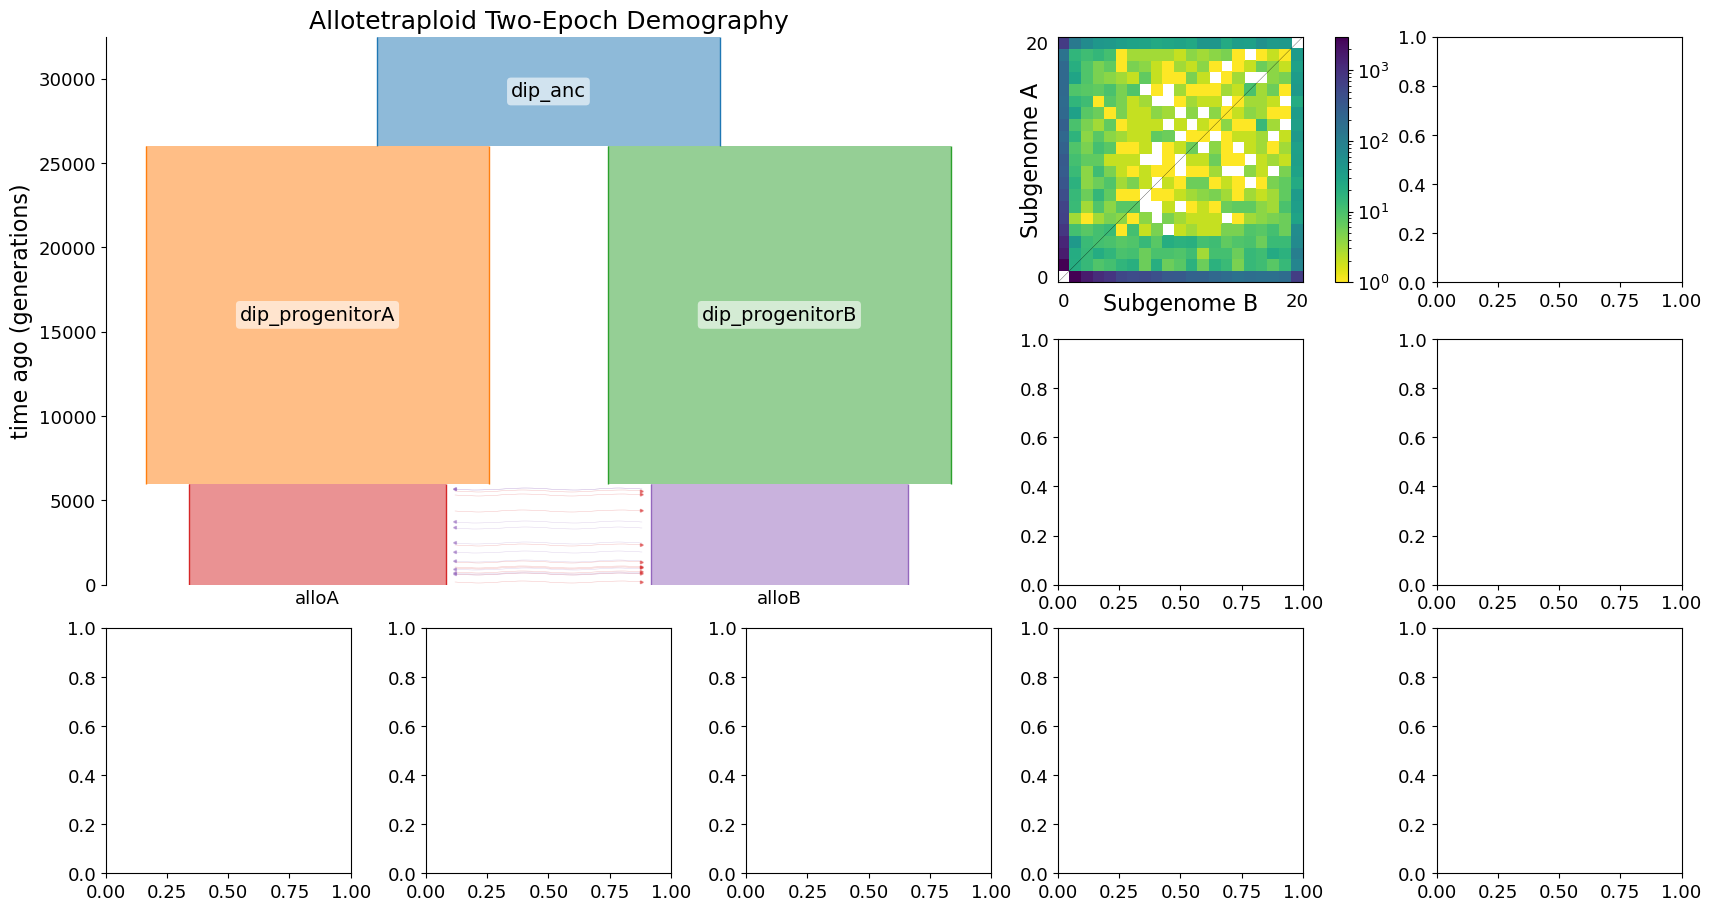

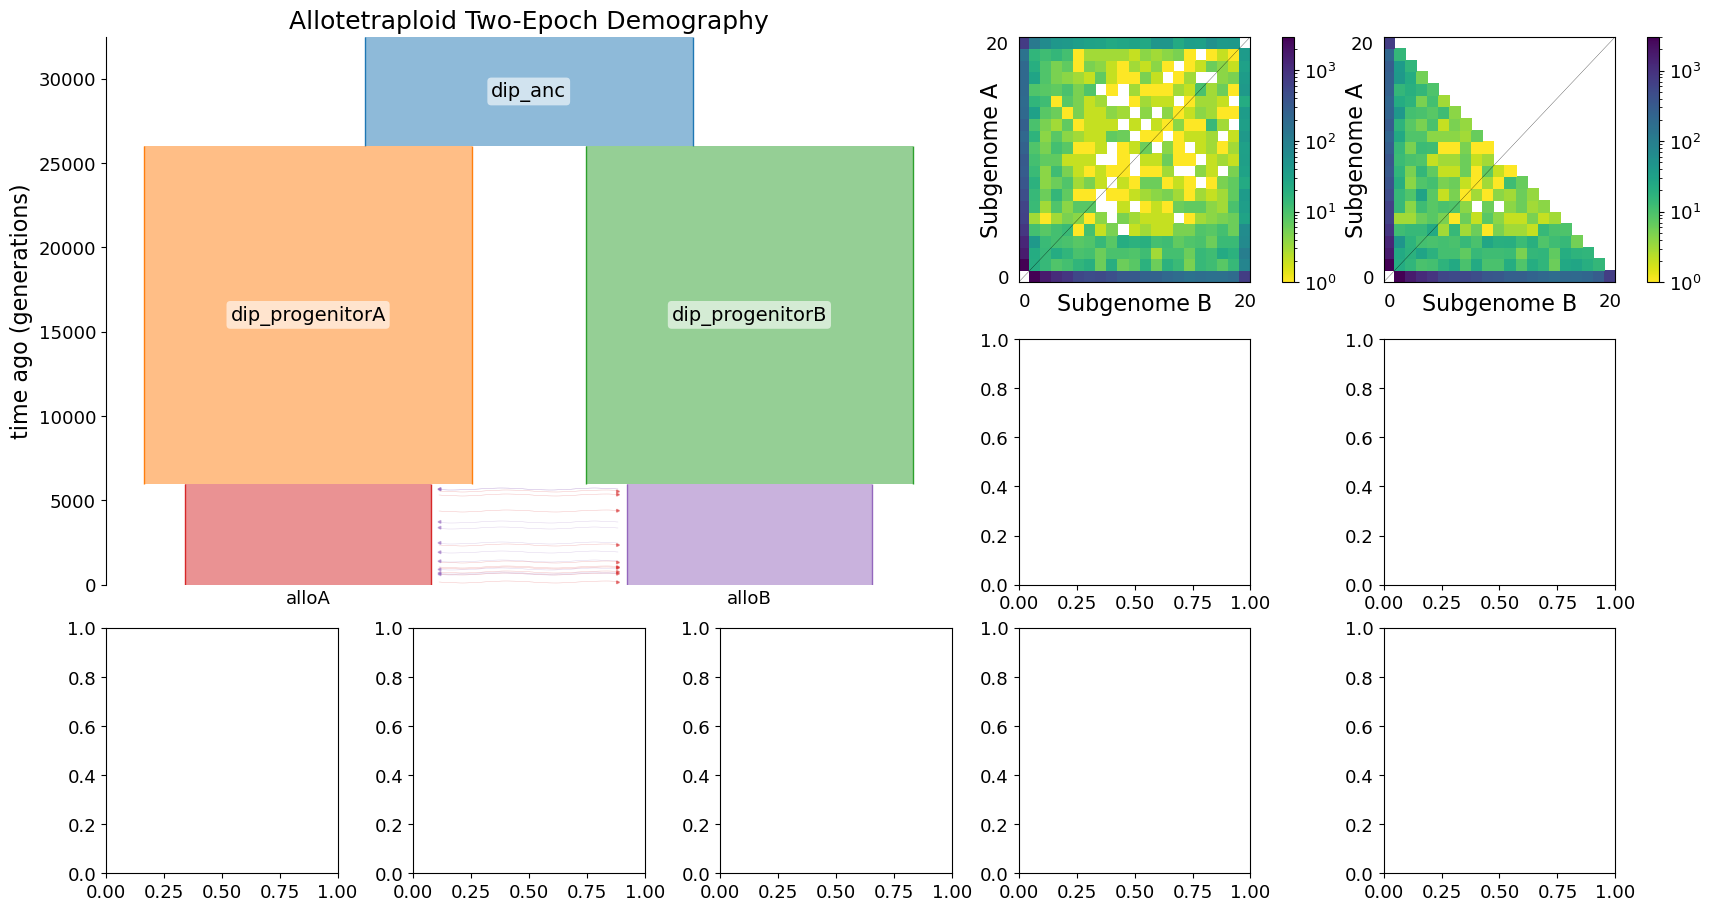

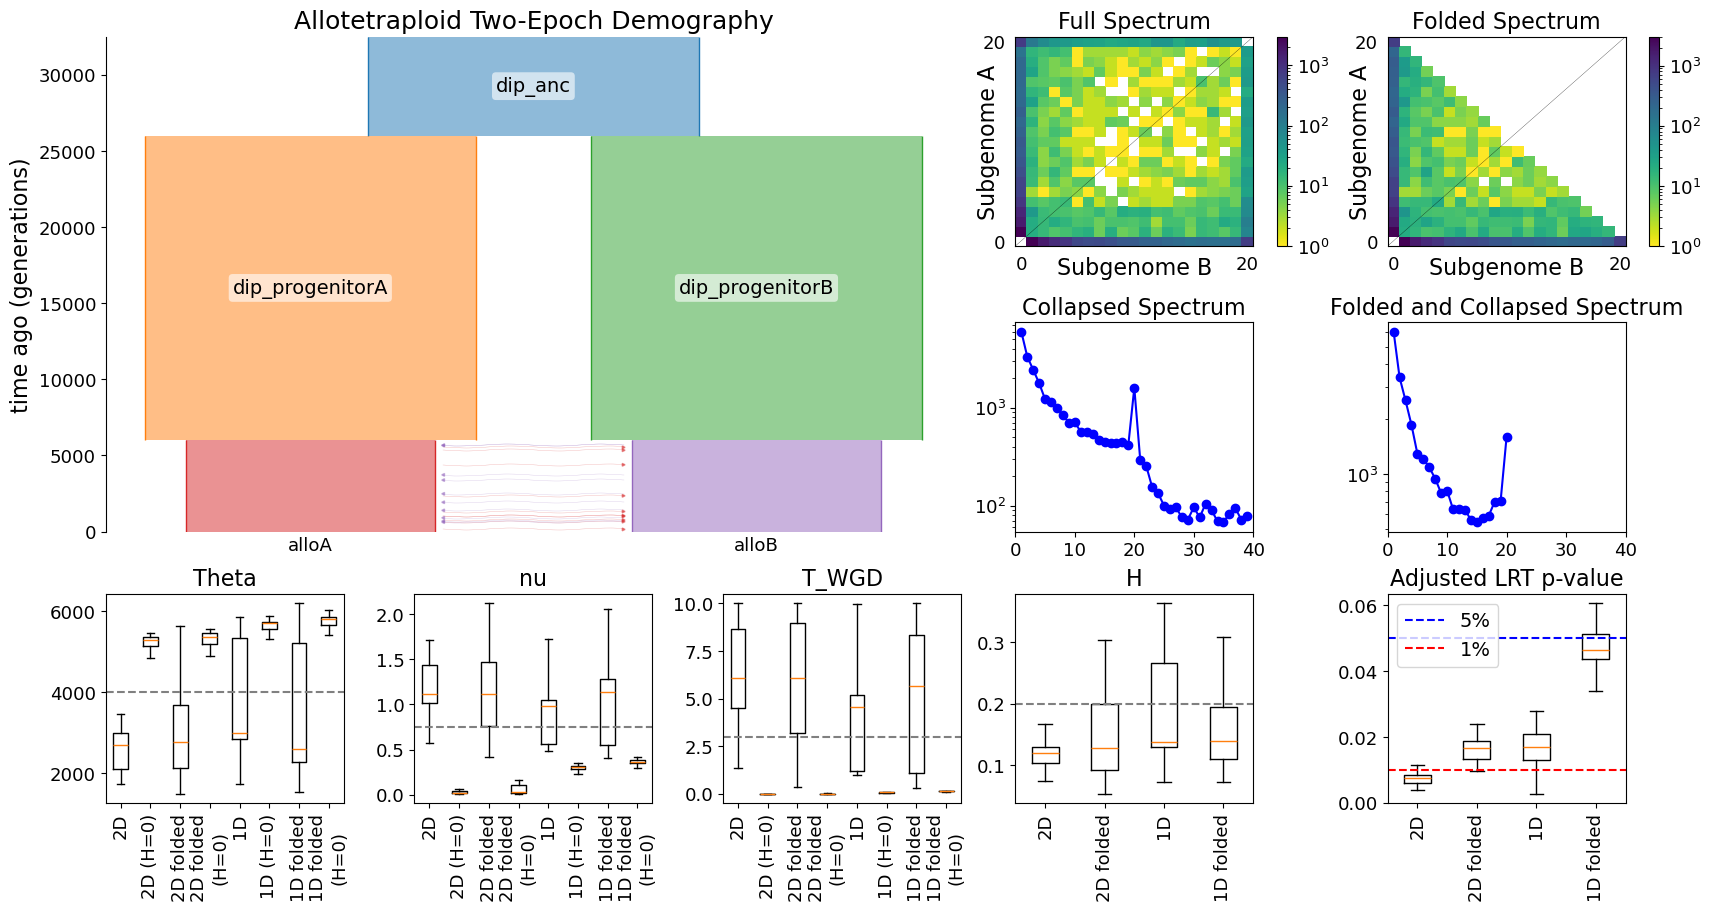

In [31]:
### MAIN TEXT FIGURE ###
fig = plt.figure(figsize=(17, 9), layout='constrained')
ax_dict = fig.subplot_mosaic(
    """
    AAABC
    AAADE
    FGHIJ
    """
)

demes_graph = demes.load('allotetraploid_demography.yaml')
demesdraw.tubes(demes_graph, ax=ax_dict['A'], title="Allotetraploid Two-Epoch Demography")


ts = tskit.load('allo_2epoch_ex.trees')

sfs = get_sfs_from_ts(ts)
sfs.mask[np.where(sfs.data == 0)] = True
plt.sca(ax_dict['B'])
dadi.Plotting.plot_single_2d_sfs(sfs, pop_ids=['Subgenome A', 'Subgenome B'])

sfs = get_sfs_from_ts(ts)
sfs = sfs.fold()
sfs.mask[np.where(sfs.data == 0)] = True
plt.sca(ax_dict['C'])
dadi.Plotting.plot_single_2d_sfs(sfs, pop_ids=['Subgenome A', 'Subgenome B'])

sfs = get_sfs_from_ts(ts)
sfs = sfs.combine_two_pops([0,1])
sfs.mask[np.where(sfs.data == 0)] = True
sfs.pop_ids = ['Collapsed Subgenomes']
plt.sca(ax_dict['D'])
ax_dict['D'].semilogy(sfs, '-ob')
ax_dict['D'].set_xlim(0, sfs.sample_sizes[0])

sfs = get_sfs_from_ts(ts)
sfs = sfs.combine_two_pops([0,1])
sfs = sfs.fold()
sfs.mask[np.where(sfs.data == 0)] = True
sfs.pop_ids = ['Collapsed Subgenomes']
plt.sca(ax_dict['E'])
ax_dict['E'].semilogy(sfs, '-ob')
ax_dict['E'].set_xlim(0, sfs.sample_sizes[0])

ax_dict['B'].set_title('Full Spectrum', fontsize=16)
ax_dict['C'].set_title('Folded Spectrum', fontsize=16)
ax_dict['D'].set_title('Collapsed Spectrum', fontsize=16)
ax_dict['E'].set_title('Folded and Collapsed Spectrum', fontsize=16)


plot_param_boxplots(ax_dict['F'], "allo_2epoch/params8/", param="theta")
plot_param_boxplots(ax_dict['G'], "allo_2epoch/params8/", param="nu")
plot_param_boxplots(ax_dict['H'], "allo_2epoch/params8/", param="T_WGD")
plot_param_boxplots(ax_dict['I'], "allo_2epoch/params8/", param="H")
plot_LRT_boxplots_linear(ax_dict['J'], "allo_2epoch/params8/", .01)

for index in ['F', 'G', 'H']:
    ax_dict[index].set_xticks([1, 2, 3, 4, 5, 6, 7, 8], 
                   ['2D', '2D (H=0)', '2D folded', '2D folded' + '\n' + '(H=0)', 
                    '1D', '1D (H=0)', '1D folded', '1D folded' + '\n' + '(H=0)'], 
                   rotation=90)

ax_dict['I'].set_xticks([1,2,3,4], ['2D', '2D folded', '1D', '1D folded'], rotation=90)

ax_dict['F'].set_title('Theta', size=16)
ax_dict['G'].set_title('nu', size=16)
ax_dict['H'].set_title('T_WGD', size=16)
ax_dict['I'].set_title('H', size=16)
ax_dict['J'].set_title('Adjusted LRT p-value', size=16)

ax_dict['F'].hlines(4000, xmin=.5, xmax=8.5, colors='gray', linestyles='dashed')
ax_dict['G'].hlines(.75, xmin=.5, xmax=8.5, colors='gray', linestyles='dashed')
ax_dict['H'].hlines(3, xmin=.5, xmax=8.5, colors='gray', linestyles='dashed')
ax_dict['I'].hlines(.2, xmin=.5, xmax=4.5, colors='gray', linestyles='dashed')
ax_dict['J'].hlines(.05, xmin=.5, xmax=4.5, colors='blue', linestyles='dashed', label='5%')
ax_dict['J'].hlines(.01, xmin=.5, xmax=4.5, colors='red', linestyles='dashed', label='1%')
ax_dict['J'].legend(loc='upper left')

plt.savefig('allo_2epoch_figure.pdf', dpi=900, format='pdf')


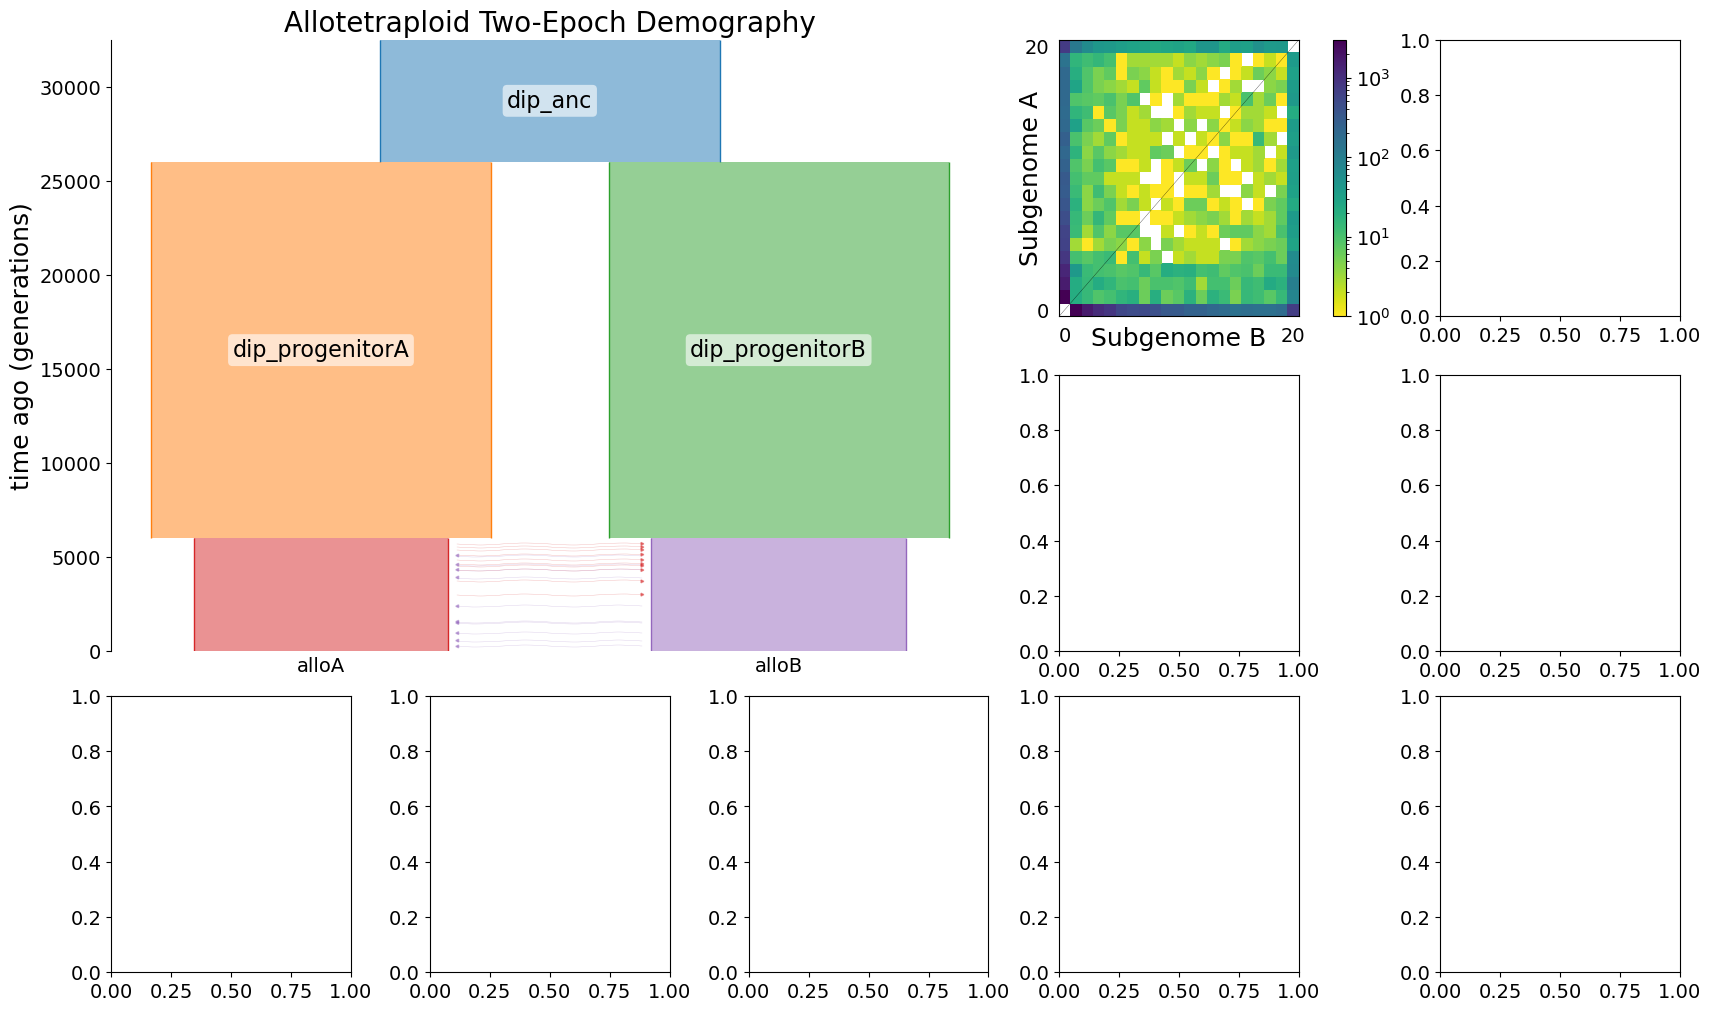

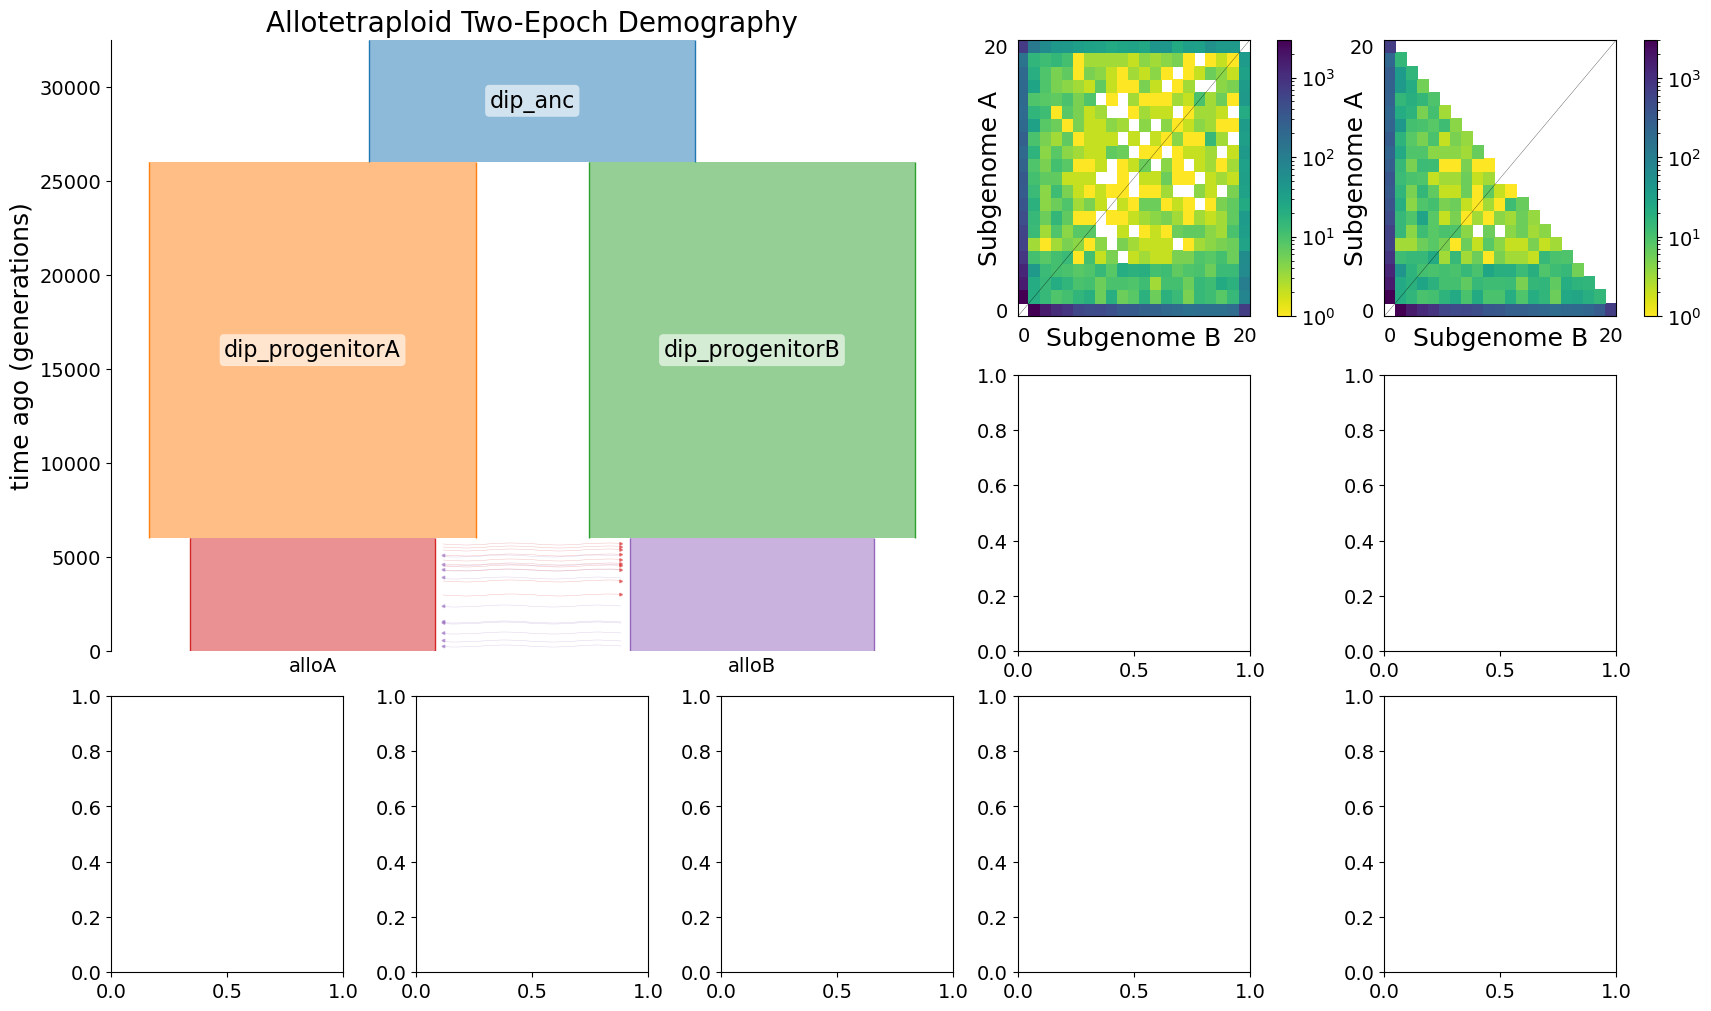

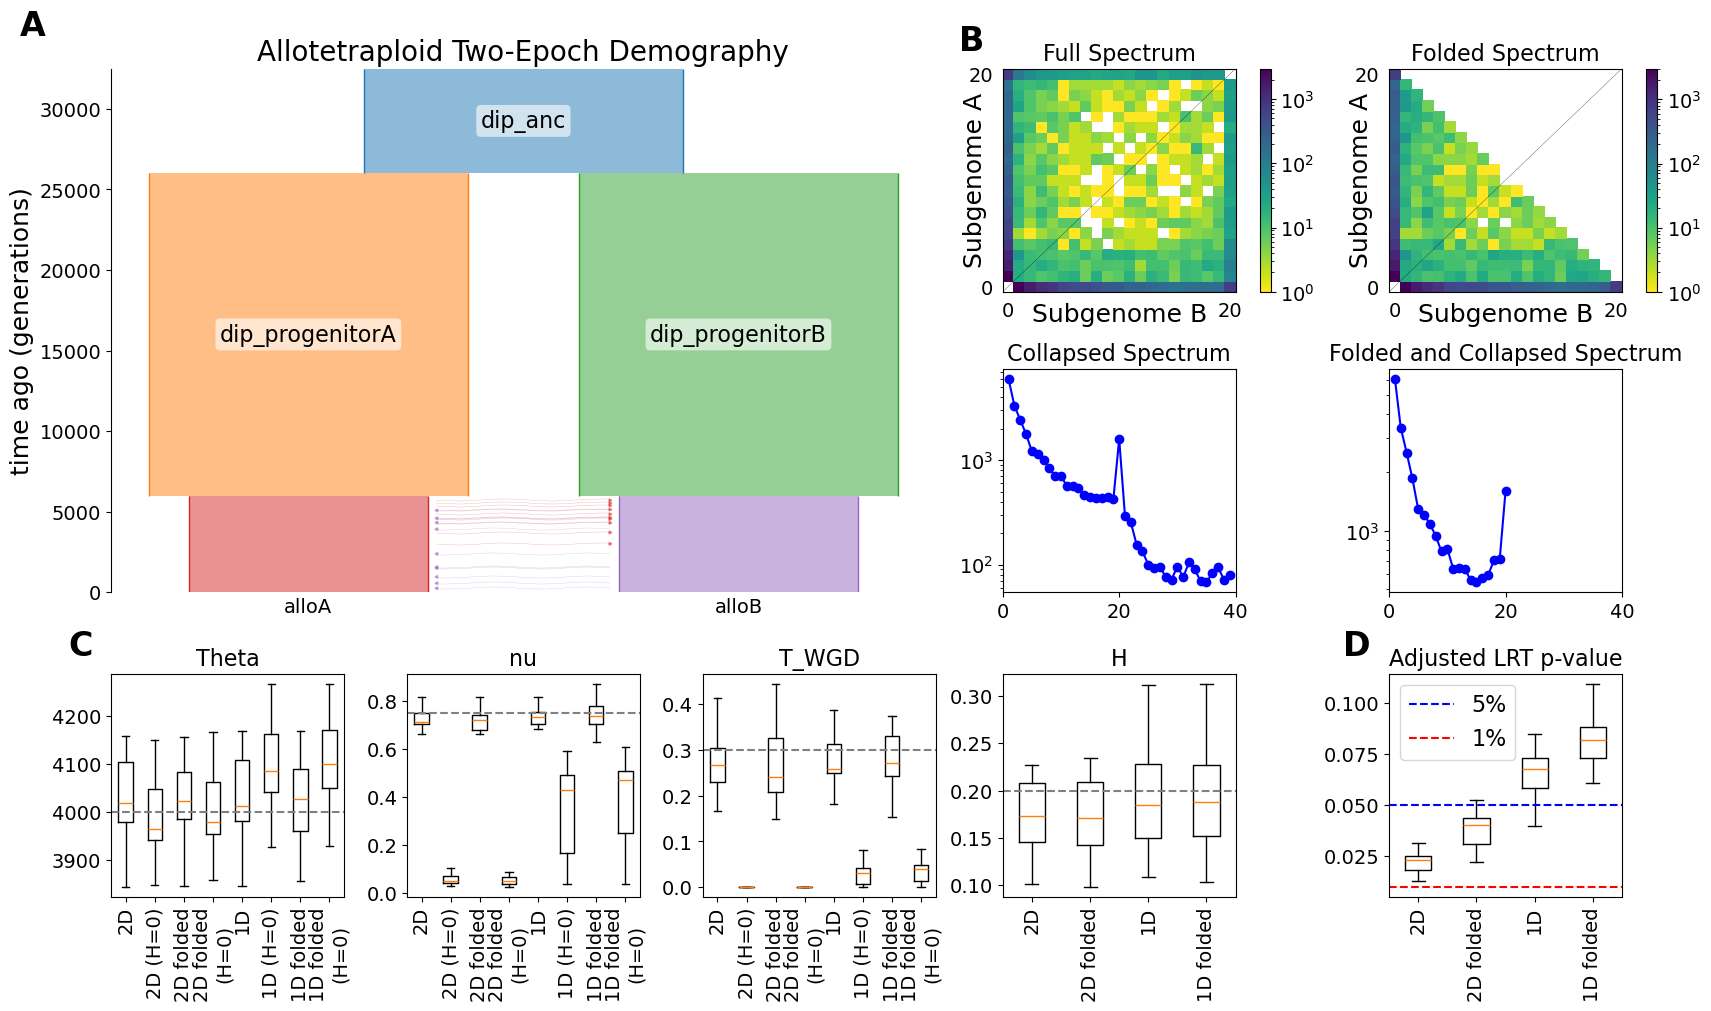

In [35]:
### MAIN TEXT FIGURE ###
fig = plt.figure(figsize=(17, 10), layout='constrained')
ax_dict = fig.subplot_mosaic(
    """
    AAABC
    AAADE
    FGHIJ
    """
)

demes_graph = demes.load('allotetraploid_demography.yaml')
demesdraw.tubes(demes_graph, ax=ax_dict['A'], title="Allotetraploid Two-Epoch Demography")


ts = tskit.load('allo_2epoch_ex2.trees')

sfs = get_sfs_from_ts(ts)
sfs.mask[np.where(sfs.data == 0)] = True
plt.sca(ax_dict['B'])
dadi.Plotting.plot_single_2d_sfs(sfs, pop_ids=['Subgenome A', 'Subgenome B'])

sfs = get_sfs_from_ts(ts)
sfs = sfs.fold()
sfs.mask[np.where(sfs.data == 0)] = True
plt.sca(ax_dict['C'])
dadi.Plotting.plot_single_2d_sfs(sfs, pop_ids=['Subgenome A', 'Subgenome B'])

sfs = get_sfs_from_ts(ts)
sfs = sfs.combine_two_pops([0,1])
sfs.mask[np.where(sfs.data == 0)] = True
sfs.pop_ids = ['Collapsed Subgenomes']
plt.sca(ax_dict['D'])
ax_dict['D'].semilogy(sfs, '-ob')
ax_dict['D'].set_xlim(0, sfs.sample_sizes[0])

sfs = get_sfs_from_ts(ts)
sfs = sfs.combine_two_pops([0,1])
sfs = sfs.fold()
sfs.mask[np.where(sfs.data == 0)] = True
sfs.pop_ids = ['Collapsed Subgenomes']
plt.sca(ax_dict['E'])
ax_dict['E'].semilogy(sfs, '-ob')
ax_dict['E'].set_xlim(0, sfs.sample_sizes[0])

ax_dict['B'].set_title('Full Spectrum', fontsize=16)
ax_dict['C'].set_title('Folded Spectrum', fontsize=16)
ax_dict['D'].set_title('Collapsed Spectrum', fontsize=16)
ax_dict['E'].set_title('Folded and Collapsed Spectrum', fontsize=16)


plot_param_boxplots(ax_dict['F'], "allo_2epoch/params7/", param="theta")
plot_param_boxplots(ax_dict['G'], "allo_2epoch/params7/", param="nu")
plot_param_boxplots(ax_dict['H'], "allo_2epoch/params7/", param="T_WGD")
plot_param_boxplots(ax_dict['I'], "allo_2epoch/params7/", param="H")
plot_LRT_boxplots_linear(ax_dict['J'], "allo_2epoch/params7/", .01)

for index in ['F', 'G', 'H']:
    ax_dict[index].set_xticks([1, 2, 3, 4, 5, 6, 7, 8], 
                   ['2D', '2D (H=0)', '2D folded', '2D folded' + '\n' + '(H=0)', 
                    '1D', '1D (H=0)', '1D folded', '1D folded' + '\n' + '(H=0)'], 
                   rotation=90)

ax_dict['I'].set_xticks([1,2,3,4], ['2D', '2D folded', '1D', '1D folded'], rotation=90)

ax_dict['F'].set_title('Theta', size=16)
ax_dict['G'].set_title('nu', size=16)
ax_dict['H'].set_title('T_WGD', size=16)
ax_dict['I'].set_title('H', size=16)
ax_dict['J'].set_title('Adjusted LRT p-value', size=16)

ax_dict['F'].hlines(4000, xmin=.5, xmax=8.5, colors='gray', linestyles='dashed')
ax_dict['G'].hlines(.75, xmin=.5, xmax=8.5, colors='gray', linestyles='dashed')
ax_dict['H'].hlines(.3, xmin=.5, xmax=8.5, colors='gray', linestyles='dashed')
ax_dict['I'].hlines(.2, xmin=.5, xmax=4.5, colors='gray', linestyles='dashed')
ax_dict['J'].hlines(.05, xmin=.5, xmax=4.5, colors='blue', linestyles='dashed', label='5%')
ax_dict['J'].hlines(.01, xmin=.5, xmax=4.5, colors='red', linestyles='dashed', label='1%')
ax_dict['J'].legend(loc='upper left')

# Add subfigure labels
ax_dict['A'].text(-0.08, 1.05, 'A', transform=ax_dict['A'].transAxes,
                  fontsize=24, fontweight='bold', va='bottom', ha='right')
ax_dict['B'].text(-0.08, 1.05, 'B', transform=ax_dict['B'].transAxes,
                  fontsize=24, fontweight='bold', va='bottom', ha='right')
ax_dict['F'].text(-0.08, 1.05, 'C', transform=ax_dict['F'].transAxes,
                  fontsize=24, fontweight='bold', va='bottom', ha='right')
ax_dict['J'].text(-0.08, 1.05, 'D', transform=ax_dict['J'].transAxes,
                  fontsize=24, fontweight='bold', va='bottom', ha='right')

plt.savefig('allo_2epoch_figure_v2.pdf', dpi=900, format='pdf')

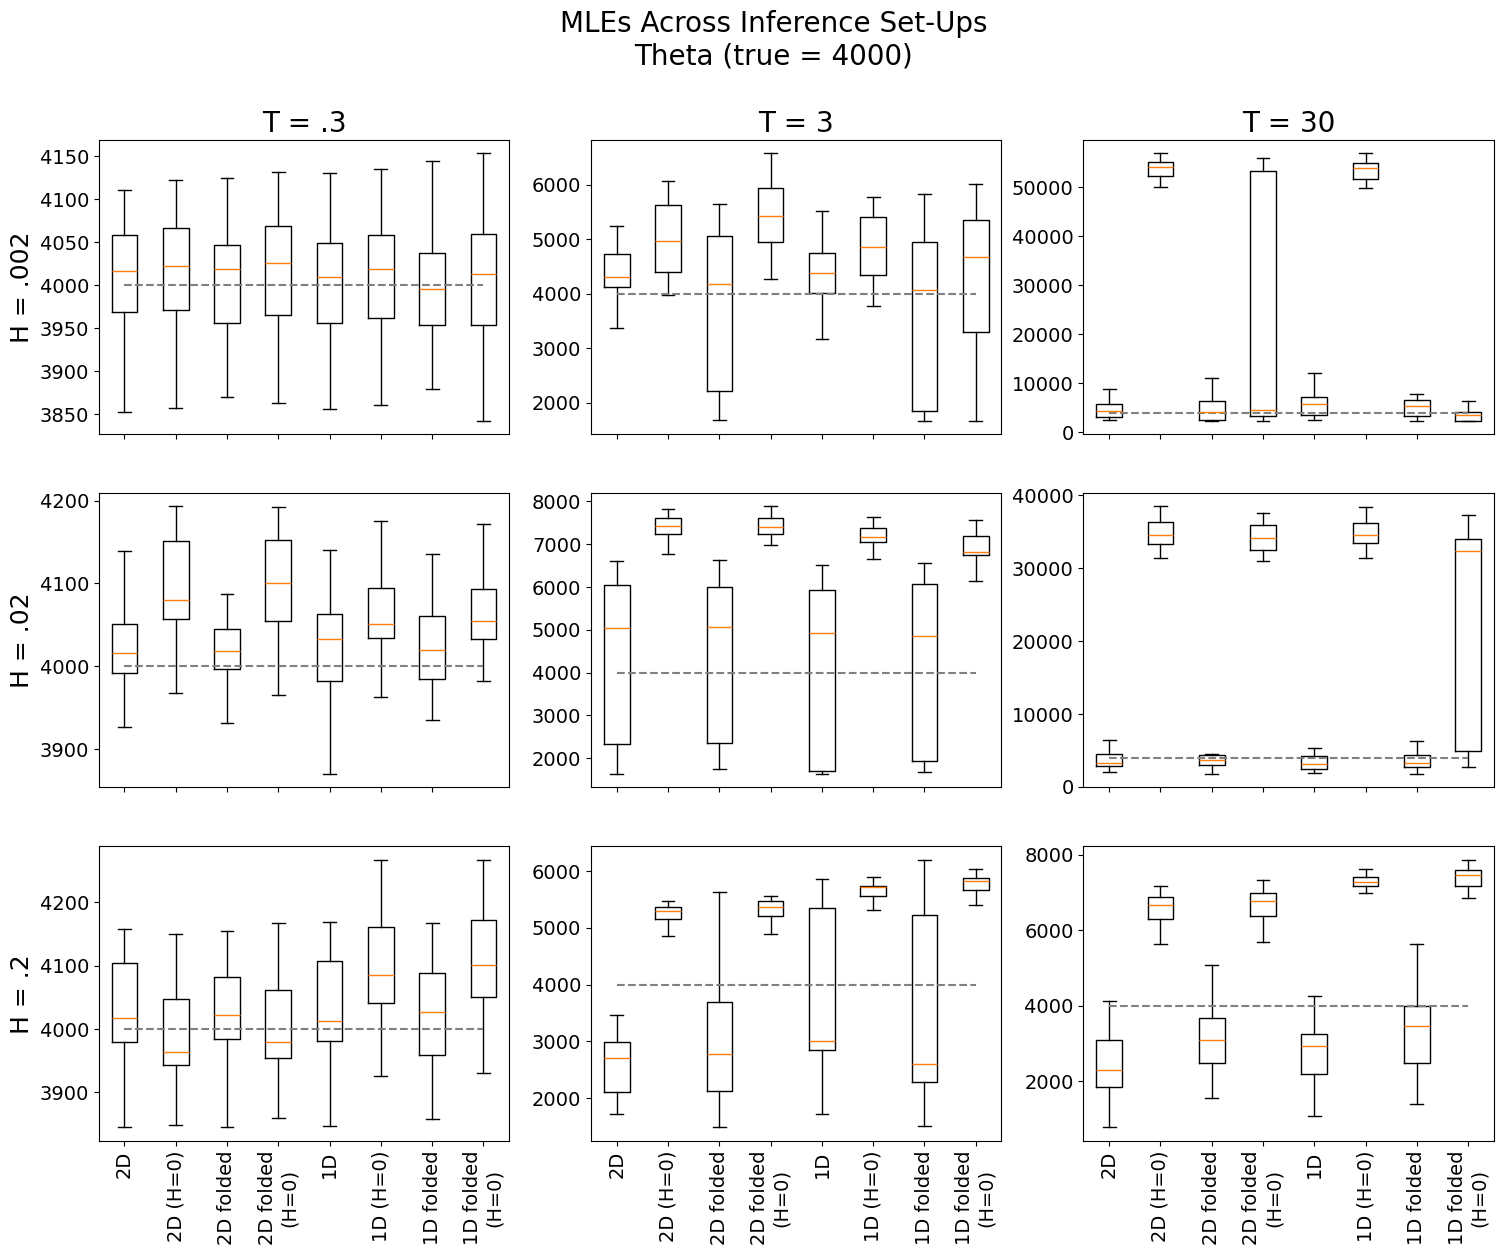

In [54]:
### SUPPLEMENTAL FIGURES ###
fig, ax = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('MLEs Across Inference Set-Ups'  + '\n' + 'Theta (true = 4000)', fontsize=20)

plot_param_boxplots(ax[0,0], "allo_2epoch/params1/", param="theta")
plot_param_boxplots(ax[0,1], "allo_2epoch/params2/", param="theta")
plot_param_boxplots(ax[0,2], "allo_2epoch/params3/", param="theta")
plot_param_boxplots(ax[1,0], "allo_2epoch/params4/", param="theta")
plot_param_boxplots(ax[1,1], "allo_2epoch/params5/", param="theta")
plot_param_boxplots(ax[1,2], "allo_2epoch/params6/", param="theta")
plot_param_boxplots(ax[2,0], "allo_2epoch/params7/", param="theta")
plot_param_boxplots(ax[2,1], "allo_2epoch/params8/", param="theta")
plot_param_boxplots(ax[2,2], "allo_2epoch/params9/", param="theta")

for j in range(3):
    ax[2,j].set_xticks([1, 2, 3, 4, 5, 6, 7, 8], 
                   ['2D', '2D (H=0)', '2D folded', '2D folded' + '\n' + '(H=0)', 
                    '1D', '1D (H=0)', '1D folded', '1D folded' + '\n' + '(H=0)'], 
                   rotation=90)

ax[0,0].set_title('T = .3')
ax[0,1].set_title('T = 3')
ax[0,2].set_title('T = 30')

ax[0,0].set_ylabel('H = .002')
ax[1,0].set_ylabel('H = .02')
ax[2,0].set_ylabel('H = .2')

for i in range(3):
    for j in range(3):
        ax[i,j].hlines(4000, xmin=1, xmax=8, colors='gray', linestyles='dashed')

fig.savefig("allo_2epoch_theta.pdf", bbox_inches='tight', format='pdf', dpi=900)

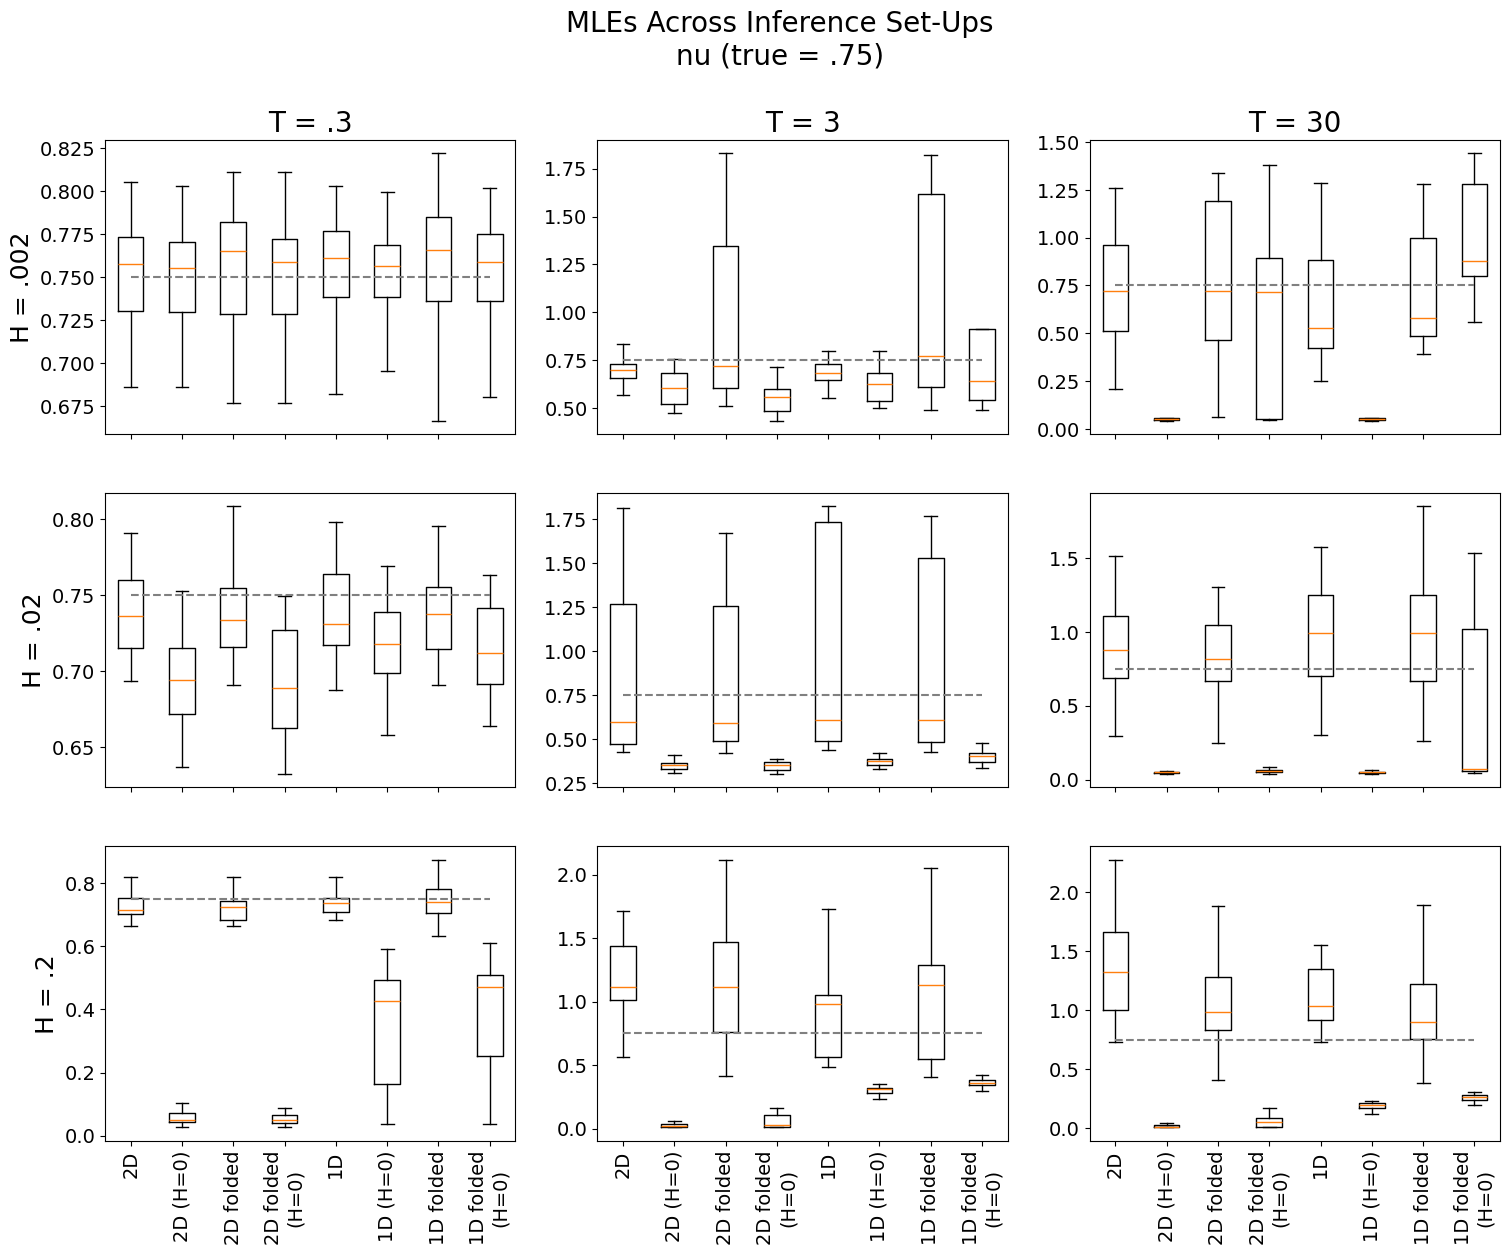

In [53]:
fig, ax = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('MLEs Across Inference Set-Ups'  + '\n' + 'nu (true = .75)', fontsize=20)

plot_param_boxplots(ax[0,0], "allo_2epoch/params1/", param="nu")
plot_param_boxplots(ax[0,1], "allo_2epoch/params2/", param="nu")
plot_param_boxplots(ax[0,2], "allo_2epoch/params3/", param="nu")
plot_param_boxplots(ax[1,0], "allo_2epoch/params4/", param="nu")
plot_param_boxplots(ax[1,1], "allo_2epoch/params5/", param="nu")
plot_param_boxplots(ax[1,2], "allo_2epoch/params6/", param="nu")
plot_param_boxplots(ax[2,0], "allo_2epoch/params7/", param="nu")
plot_param_boxplots(ax[2,1], "allo_2epoch/params8/", param="nu")
plot_param_boxplots(ax[2,2], "allo_2epoch/params9/", param="nu")

for j in range(3):
    ax[2,j].set_xticks([1, 2, 3, 4, 5, 6, 7, 8], 
                   ['2D', '2D (H=0)', '2D folded', '2D folded' + '\n' + '(H=0)', 
                    '1D', '1D (H=0)', '1D folded', '1D folded' + '\n' + '(H=0)'], 
                   rotation=90)

ax[0,0].set_title('T = .3')
ax[0,1].set_title('T = 3')
ax[0,2].set_title('T = 30')

ax[0,0].set_ylabel('H = .002')
ax[1,0].set_ylabel('H = .02')
ax[2,0].set_ylabel('H = .2')


for i in range(3):
    for j in range(3):
        ax[i,j].hlines(.75, xmin=1, xmax=8, colors='gray', linestyles='dashed')

fig.savefig("allo_2epoch_nu.pdf", bbox_inches='tight', format='pdf', dpi=900)

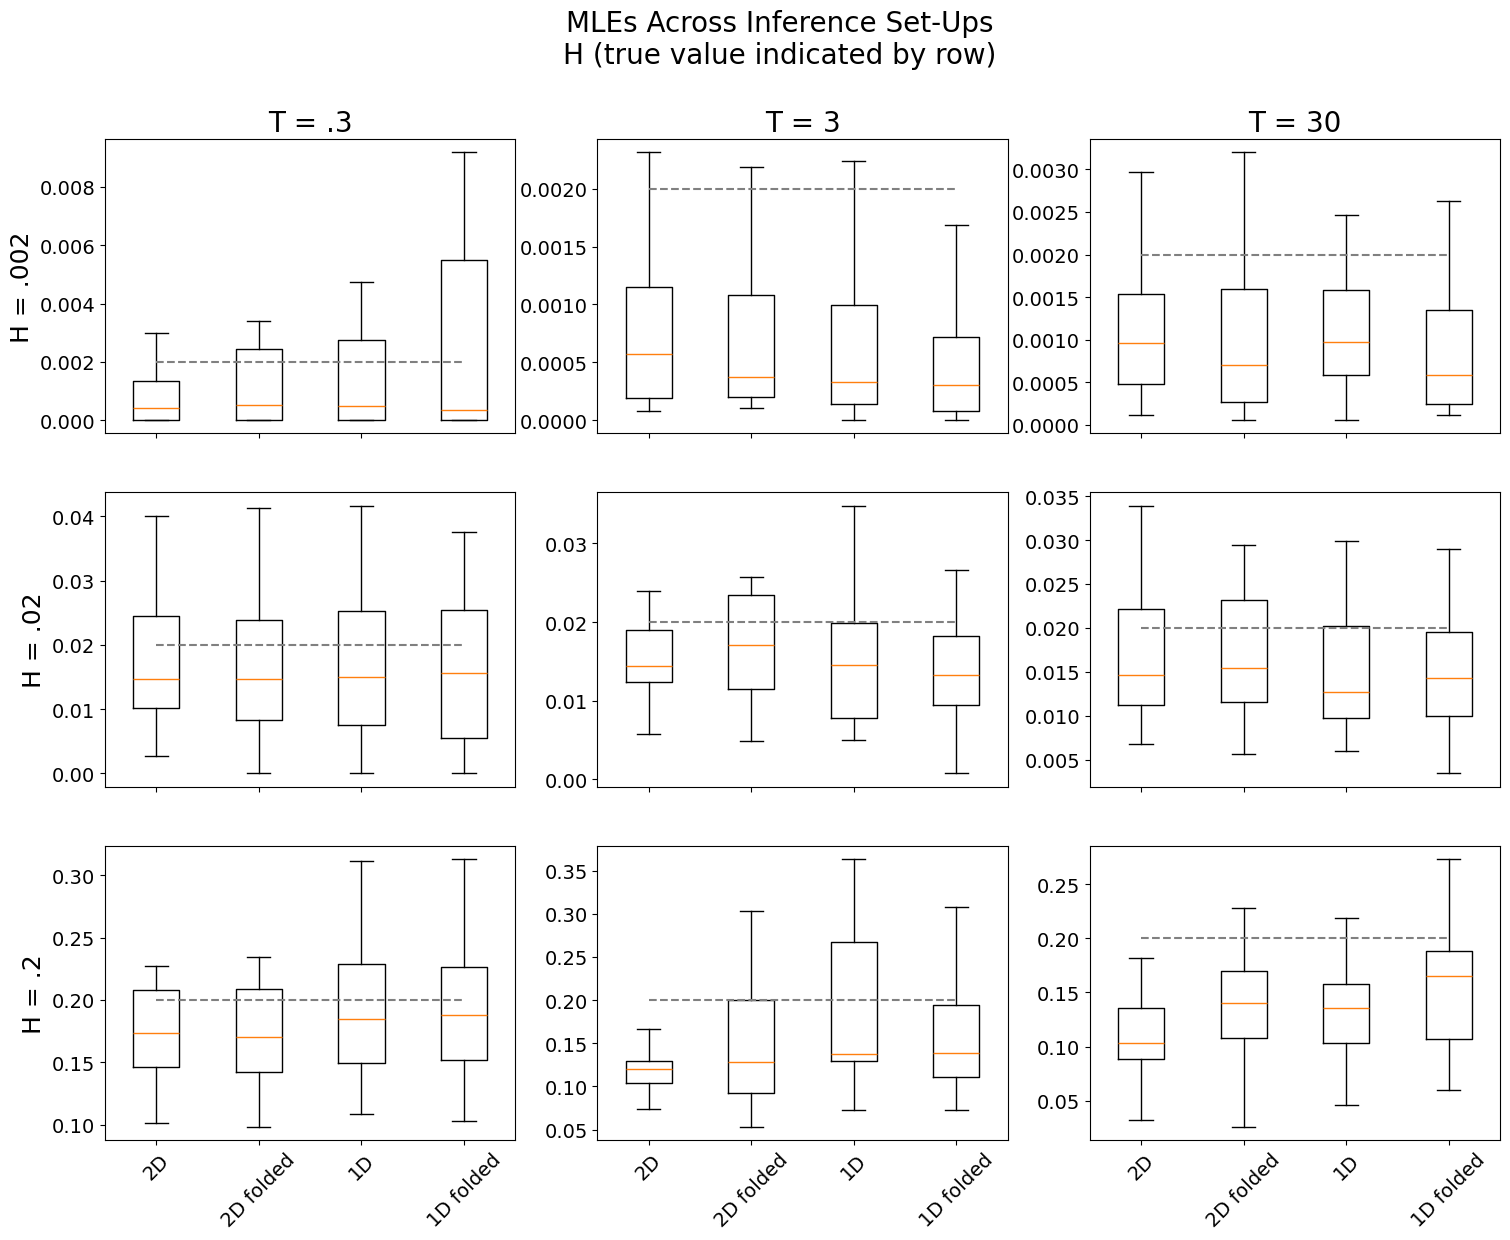

In [57]:
fig, ax = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('MLEs Across Inference Set-Ups'  + '\n' + 'H (true value indicated by row)', fontsize=20)

plot_param_boxplots(ax[0,0], "allo_2epoch/params1/", param="H")
plot_param_boxplots(ax[0,1], "allo_2epoch/params2/", param="H")
plot_param_boxplots(ax[0,2], "allo_2epoch/params3/", param="H")
plot_param_boxplots(ax[1,0], "allo_2epoch/params4/", param="H")
plot_param_boxplots(ax[1,1], "allo_2epoch/params5/", param="H")
plot_param_boxplots(ax[1,2], "allo_2epoch/params6/", param="H")
plot_param_boxplots(ax[2,0], "allo_2epoch/params7/", param="H")
plot_param_boxplots(ax[2,1], "allo_2epoch/params8/", param="H")
plot_param_boxplots(ax[2,2], "allo_2epoch/params9/", param="H")

ax[0,0].set_title('T = .3')
ax[0,1].set_title('T = 3')
ax[0,2].set_title('T = 30')

ax[0,0].set_ylabel('H = .002')
ax[1,0].set_ylabel('H = .02')
ax[2,0].set_ylabel('H = .2')

for j in range(3):
    ax[2,j].set_xticks([1, 2, 3, 4], 
                   ['2D', '2D folded', '1D', '1D folded'], 
                   rotation=45)

for i in range(3):
        ax[0,i].hlines(.002, xmin=1, xmax=4, colors='gray', linestyles='dashed')
        ax[1,i].hlines(.02, xmin=1, xmax=4, colors='gray', linestyles='dashed')
        ax[2,i].hlines(.2, xmin=1, xmax=4, colors='gray', linestyles='dashed')

fig.savefig("allo_2epoch_H.pdf", bbox_inches='tight', format='pdf', dpi=900)

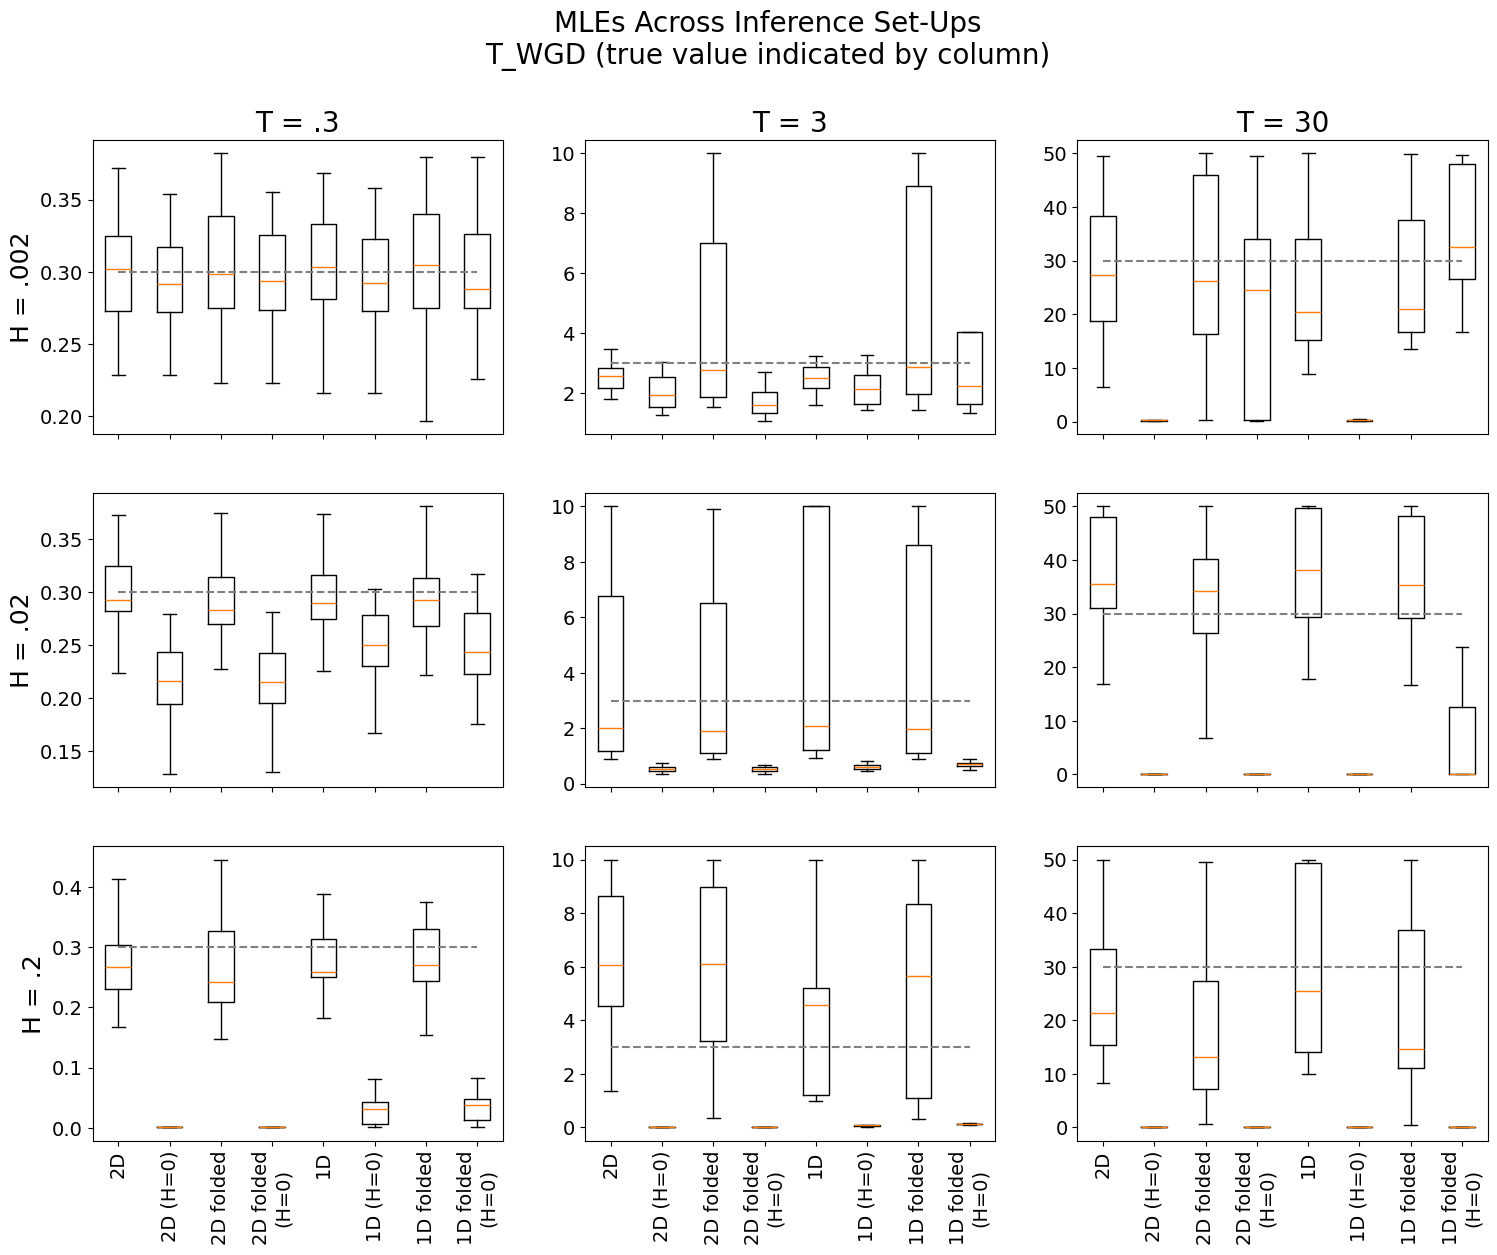

In [58]:
fig, ax = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle('MLEs Across Inference Set-Ups'  + '\n' + 'T_WGD (true value indicated by column)', fontsize=20)

plot_param_boxplots(ax[0,0], "allo_2epoch/params1/", param="T_WGD")
plot_param_boxplots(ax[0,1], "allo_2epoch/params2/", param="T_WGD")
plot_param_boxplots(ax[0,2], "allo_2epoch/params3/", param="T_WGD")
plot_param_boxplots(ax[1,0], "allo_2epoch/params4/", param="T_WGD")
plot_param_boxplots(ax[1,1], "allo_2epoch/params5/", param="T_WGD")
plot_param_boxplots(ax[1,2], "allo_2epoch/params6/", param="T_WGD")
plot_param_boxplots(ax[2,0], "allo_2epoch/params7/", param="T_WGD")
plot_param_boxplots(ax[2,1], "allo_2epoch/params8/", param="T_WGD")
plot_param_boxplots(ax[2,2], "allo_2epoch/params9/", param="T_WGD")

for j in range(3):
    ax[2,j].set_xticks([1, 2, 3, 4, 5, 6, 7, 8], 
                   ['2D', '2D (H=0)', '2D folded', '2D folded' + '\n' + '(H=0)', 
                    '1D', '1D (H=0)', '1D folded', '1D folded' + '\n' + '(H=0)'], 
                   rotation=90)

ax[0,0].set_title('T = .3')
ax[0,1].set_title('T = 3')
ax[0,2].set_title('T = 30')

ax[0,0].set_ylabel('H = .002')
ax[1,0].set_ylabel('H = .02')
ax[2,0].set_ylabel('H = .2')

for i in range(3):
        ax[i,0].hlines(.3, xmin=1, xmax=8, colors='gray', linestyles='dashed')
        ax[i,1].hlines(3, xmin=1, xmax=8, colors='gray', linestyles='dashed')
        ax[i,2].hlines(30, xmin=1, xmax=8, colors='gray', linestyles='dashed')

fig.savefig('allo_2epoch_T_WGD.pdf', bbox_inches='tight', format='pdf', dpi=900)

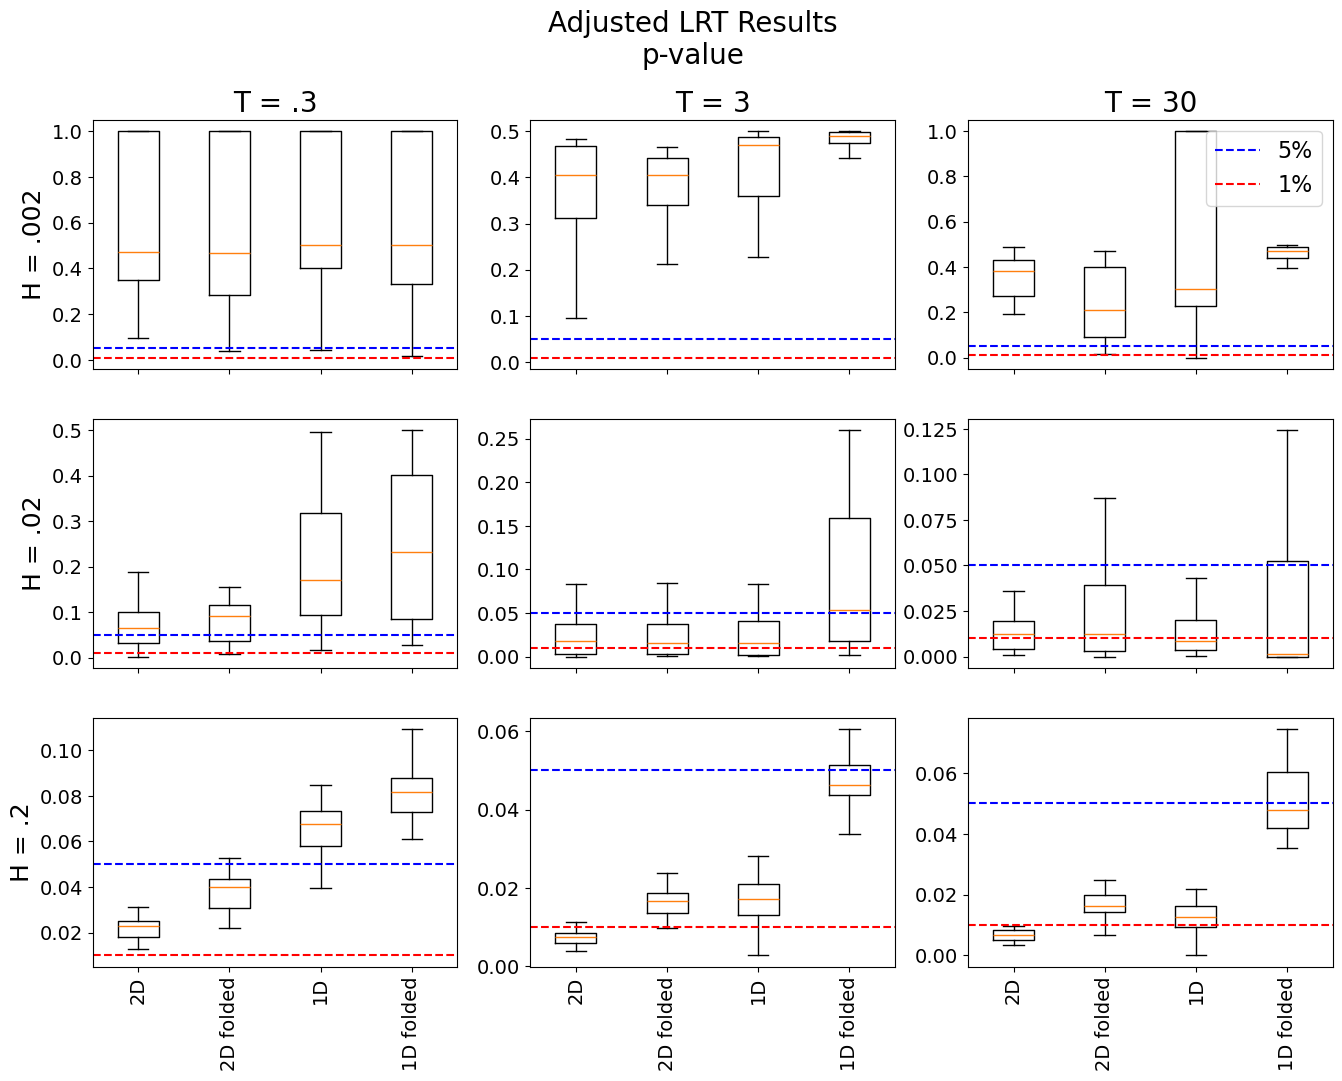

In [74]:
fig, ax = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle('Adjusted LRT Results'  + '\n' + 'p-value', fontsize=20)

plot_LRT_boxplots_linear(ax[0,0], "allo_2epoch/params1/", .01)
plot_LRT_boxplots_linear(ax[0,1], "allo_2epoch/params2/", .01)
plot_LRT_boxplots_linear(ax[0,2], "allo_2epoch/params3/", .01)
plot_LRT_boxplots_linear(ax[1,0], "allo_2epoch/params4/", .01)
plot_LRT_boxplots_linear(ax[1,1], "allo_2epoch/params5/", .01)
plot_LRT_boxplots_linear(ax[1,2], "allo_2epoch/params6/", .01)
plot_LRT_boxplots_linear(ax[2,0], "allo_2epoch/params7/", .01)
plot_LRT_boxplots_linear(ax[2,1], "allo_2epoch/params8/", .01)
plot_LRT_boxplots_linear(ax[2,2], "allo_2epoch/params9/", .01)

for i in range(3):
    for j in range(3):
        #ax[i,j].set_yscale('log')
        ax[i,j].hlines(y=.05, xmin=0.5, xmax=4.5, colors='blue', linestyles='dashed', label='5%')
        ax[i,j].hlines(y=.01, xmin=0.5, xmax=4.5, colors='red', linestyles='dashed', label='1%')
        if i!=2:
            ax[i,j].set_xticks([1, 2, 3, 4], 
                       ['', '', '', ''])
            

ax[0,2].legend(loc='upper right')

ax[0,0].set_title('T = .3')
ax[0,1].set_title('T = 3')
ax[0,2].set_title('T = 30')

ax[0,0].set_ylabel('H = .002')
ax[1,0].set_ylabel('H = .02')
ax[2,0].set_ylabel('H = .2')

fig.savefig("allo_2epoch_adjusted_LRT.pdf", bbox_inches='tight', format='pdf', dpi=900)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

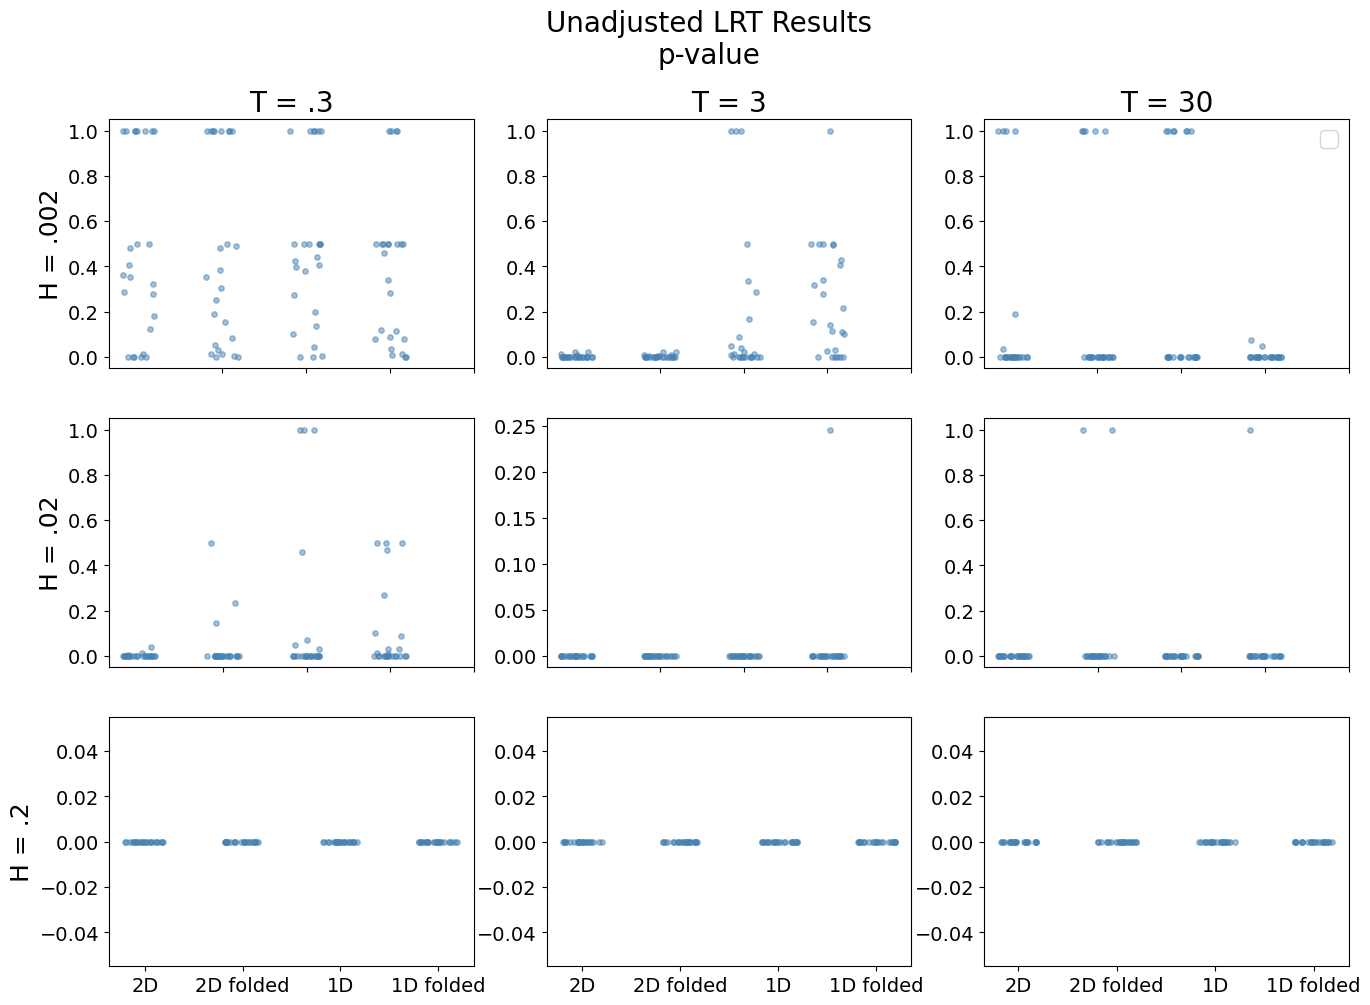

In [75]:
fig, ax = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle('Unadjusted LRT Results'  + '\n' + 'p-value', fontsize=20)

plot_LRT_boxplots(ax[0,0], "allo_2epoch/params1/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[0,1], "allo_2epoch/params2/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[0,2], "allo_2epoch/params3/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[1,0], "allo_2epoch/params4/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[1,1], "allo_2epoch/params5/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[1,2], "allo_2epoch/params6/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[2,0], "allo_2epoch/params7/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[2,1], "allo_2epoch/params8/", .01, plot_unadj=True)
plot_LRT_boxplots(ax[2,2], "allo_2epoch/params9/", .01, plot_unadj=True)

for i in range(3):
    for j in range(3):
        #ax[i,j].set_yscale('log')
        if i!=2:
            ax[i,j].set_xticks([1, 2, 3, 4], 
                       ['', '', '', ''])
            

ax[0,2].legend(loc='upper right')

ax[0,0].set_title('T = .3')
ax[0,1].set_title('T = 3')
ax[0,2].set_title('T = 30')

ax[0,0].set_ylabel('H = .002')
ax[1,0].set_ylabel('H = .02')
ax[2,0].set_ylabel('H = .2')

fig.savefig("allo_2epoch_LRTs.pdf", bbox_inches='tight', format='pdf', dpi=900)
